In [23]:
mother_occupation = {
  0: "Student",
  1: "Director/Executive Manager",
  2: "Scientist/Intellectual Specialist",
  3: "Intermediate Technician",
  4: "Administrative Staff",
  5: "Service/Security/Sales Worker",
  6: "Skilled Agricultural Worker",
  7: "Skilled Industry/Construction Worker",
  8: "Machine Operator/Assembly Worker",
  9: "Unskilled Laborer/Worker",
  10: "Armed Forces/Defense Personnel",
  90: "Other/Home Maker",
  99: "Not Specified",
  122: "Health Professional (Doctor/Nurse)",
  123: "Teacher/Academician",
  125: "ICT/IT Specialist",
  131: "Science/Engineering Technician",
  132: "Medical/Health Technician",
  134: "Legal/Social/Cultural Technician",
  141: "Secretary/Data Entry Operator",
  143: "Accounting/Financial Clerk",
  144: "Admin Support Staff",
  151: "Personal Service Worker",
  52: "Salesperson/Shop Assistant",
  153: "Personal Care Worker/Aya",
  171: "Construction/Trade Worker",
  173: "Jeweler/Artisan/Precision Worker",
  175: "Food/Wood/Textile Industry Worker",
  191: "Cleaning/Domestic Worker",
  192: "Unskilled Agricultural Laborer",
  193: "Unskilled Construction/Factory Laborer",
  194: "Meal Prep Assistant/Helper"
}
father_ocupation= {
  0: "Student",
  1: "Director/Government Executive",
  2: "Scientist/Academic Specialist",
  3: "Junior Manager/Technician",
  4: "Administrative/Clerical Staff",
  5: "Service/Security/Sales Worker",
  6: "Skilled Farmer/Fisherman",
  7: "Skilled Industrial/Craft Worker",
  8: "Plant/Machine Operator",
  9: "Unskilled Laborer",
  10: "Defense/Armed Forces",
  90: "Other (Incl. Home Maker)",
  99: "Not Specified",
  101: "Armed Forces Officer",
  102: "Armed Forces Sergeant/JCO",
  103: "Soldier/Other Defense Personnel",
  112: "Commercial/Admin Director",
  114: "Hotel/Trade Manager",
  121: "Engineer/Math/Science Specialist",
  122: "Health Professional (Doctor/Specialist)",
  123: "School/College Teacher",
  124: "Finance/PR Specialist",
  131: "Science/Engineering Technician",
  132: "Medical/Paramedic Staff",
  134: "Legal/Social Work Technician",
  135: "IT/ICT Technician",
  141: "Secretary/Stenographer",
  143: "Account/Finance Clerk",
  144: "Office Admin Support",
  151: "Personal Service Worker",
  152: "Salesman/Shopkeeper",
  153: "Personal Care Worker/Attendant",
  154: "Security Guard/Police/Protection",
  161: "Commercial Farmer",
  163: "Subsistence Farmer/Fisherman",
  171: "Mason/Construction Worker",
  172: "Metal/Metallurgy Worker",
  174: "Electrician/Electronics Worker",
  175: "Food/Garment/Wood Industry Worker",
  181: "Plant/Factory Operator",
  182: "Assembly Line Worker",
  183: "Driver/Mobile Equipment Operator",
  192: "Agricultural Laborer",
  193: "Construction/Manufacturing Laborer",
  194: "Kitchen Helper/Canteen Worker",
  195: "Street Vendor/Service Provider"
}
courses = {
    1: 'B.Tech Biofuel', 2: 'B.Sc Animation', 3: 'B.Des Comm', 4: 'Vet Nursing',
    5: 'B.Tech IT', 6: 'Social Work', 7: 'B.Sc Agri', 8: 'Tourism',
    9: 'BBA Evening', 10: 'BBA', 11: 'Social Work Eve', 12: 'B.Sc Nursing',
    13: 'Animal Husbandry', 14: 'BBA Marketing', 15: 'BA Journalism',
    16: 'Oral Hygiene', 17: 'Basic Education'
}
father_education_labels = {
    1: 'Post-Graduate/Doctorate',
    2: 'Graduate',
    3: 'Diploma/Technical',
    4: 'Higher Secondary (12th)',
    5: 'Secondary (10th)',
    6: 'Middle School',
    7: 'Primary School',
    8: 'Illiterate/Unknown'
}
mother_education_labels = {
    1: 'Post-Graduate/Doctorate',
    2: 'Graduate',
    3: 'Higher Secondary (12th)',
    4: 'Secondary (10th)',
    5: 'Middle School/Below'
}

In [24]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
df = pd.read_csv('dataset.csv')

In [26]:
df = df[df['Target'] != 'Enrolled']
df = df.drop('Nacionality', axis=1)
df = df.drop('Curricular units 1st sem (credited)', axis=1)
df = df.drop('Curricular units 2nd sem (credited)', axis=1)
df = df.drop('Curricular units 1st sem (without evaluations)', axis=1)
df = df.drop('Curricular units 2nd sem (without evaluations)', axis=1)
df = df.drop('Educational special needs', axis=1)

In [27]:
category_map = {
    1: 1, 4: 1, 9: 1,3 : 1,11: 1, 13: 1, 14: 1, 17: 1, 18: 1, #merit
    12: 2, 6: 2, 5: 2, 16: 2, 15: 2, 57: 2, #quota
    7: 3, 44: 3, 53: 3, # lateral
    42: 4, 43: 4, 51: 4, #transfer
    8: 5, #mature
    2: 6, 10: 6, 26: 6, 27: 6 #ordinance
}
category={1:'Merit', 2:'Quota', 3:'Lateral', 4:'Transfer', 5:'Mature', 6:'Ordinance'}

df['Application mode'] = df['Application mode'].map(category_map)
education_id_map = {
    # Post-Graduate & Above
    4: 1, 5: 1, 
    # Graduate / Bachelors
    2: 2, 3: 2, 6: 2, 40: 2,
    # Higher Secondary (Class 12 / Intermediate)
    1: 3, 9: 3, 11: 3, 12: 3, 13: 3,
    # Secondary (Class 10 / Matriculation)
    14: 4, 15: 4, 16: 4, 19: 4,
    # Middle School & Below
    7: 5, 8: 5, 10: 5, 17: 5, 38: 5, 44: 5
}

df['Previous qualification'] = df['Previous qualification'].map(education_id_map)
#print(df['Previous qualification'].value_counts())

education_id_map = {
    # 1: Post-Graduate & Above (Masters, PhD, Specialized)
    4: 1, 5: 1, 41: 1, 43: 1, 44: 1,
    # 2: Graduate / Professional Degree (Bachelors, B.Tech, MBBS)
    2: 2, 3: 2, 6: 2, 40: 2,
    # 3: Diploma / Technical / Vocational (ITI, Polytechnic)
    22: 3, 39: 3, 42: 3, 18: 3,
    # 4: Senior Secondary (Class 11 & 12 / Intermediate)
    1: 4, 9: 4, 12: 4, 27: 4,
    # 5: Secondary (Class 9 & 10 / Matriculation)
    14: 5, 19: 5, 29: 5,
    # 6: Middle School (Class 6 to 8)
    10: 6, 11: 6, 26: 6, 30: 6, 38: 6,
    # 7: Primary School (Class 1 to 5)
    37: 7, 36: 7,
    # 8: No Formal Education / Literacy only
    35: 8, 34: 8
}

df["Father's qualification"] = df["Father's qualification"].map(education_id_map)
df["Mother's qualification"] = df["Mother's qualification"].map(education_id_map)
df["Father's qualification"].value_counts()
df["Mother's qualification"].value_counts()

Mother's qualification
4.0    873
3.0    843
2.0    401
5.0    129
1.0     50
6.0     47
Name: count, dtype: int64

In [28]:
# converted the values from string to int Graduate = 1 and Dropout = 0
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

In [29]:
df['Credit_Failure_Rate 1st sem'] = (df['Curricular units 1st sem (enrolled)'] -  df['Curricular units 1st sem (approved)'])
df['Credit_Failure_Rate 2nd sem'] = (df['Curricular units 2nd sem (enrolled)'] -  df['Curricular units 2nd sem (approved)'])

In [30]:

X = df.drop('Target', axis=1)
y = df['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Marital status                          3630 non-null   int64  
 1   Application mode                        3630 non-null   int64  
 2   Application order                       3630 non-null   int64  
 3   Course                                  3630 non-null   int64  
 4   Daytime/evening attendance              3630 non-null   int64  
 5   Previous qualification                  3630 non-null   int64  
 6   Mother's qualification                  2343 non-null   float64
 7   Father's qualification                  2919 non-null   float64
 8   Mother's occupation                     3630 non-null   int64  
 9   Father's occupation                     3630 non-null   int64  
 10  Displaced                               3630 non-null   int64  
 11  Debtor 

In [32]:
# data is split into test and traning here 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [33]:


y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       277
           1       0.91      0.95      0.93       449

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



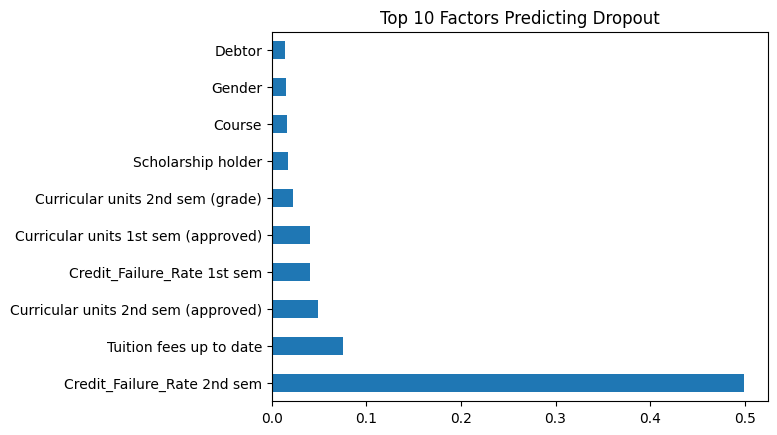

In [34]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Factors Predicting Dropout")
plt.show()

In [35]:
model.save_model('dropout_model.json')